In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
S0 = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S0_sample.h5")
# Sup = jsm_ancillary.load_sample("../../../StellarHalo/data/dynamical_friction/DF_up.h5")
# Sdown = jsm_ancillary.load_sample("../../../StellarHalo/data/dynamical_friction/DF_down.h5")
# Sdowndown = jsm_ancillary.load_sample("../../../StellarHalo/data/dynamical_friction/DF_downdown.h5")
# SHR = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S0HR_sample.h5")
# Soff = jsm_ancillary.load_sample("../../../StellarHalo/data/dynamical_friction/DF_off.h5")

S15 = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S15_sample.h5")
S30 = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S30_sample.h5")

In [4]:
S15.keys()

Index(['MAH', 'MAH_ICL', 'MAH_stellar', 'MW_est', 'Mstar_ICL', 'Mstar_acc',
       'Mstar_lost', 'Mstar_sat', 'Mstar_tot', 'Nhalo', 'Nrank', 'host_Rvir',
       'host_Vcirc', 'host_mass', 'host_stellarmass', 'host_z10', 'host_z50',
       'host_z90', 'sat_N90', 'sat_acc_c', 'sat_acc_mass', 'sat_acc_order',
       'sat_acc_stellarmass', 'sat_cumsum', 'sat_fates', 'sat_final_rmag',
       'sat_final_vmag', 'sat_mass', 'sat_order', 'sat_stellarmass',
       'sat_zacc', 'sat_zacc_proper', 'sat_zfinal'],
      dtype='object')

In [5]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [6]:
def measure_abundance_correlation(sample, mass_res, mask_orders=None, plot=True):

    final_mass = jsm_ancillary.make_matrix(sample, "sat_mass")
    final_rmag = jsm_ancillary.make_matrix(sample, "sat_final_rmag")
    try:
        host_rvir = jsm_ancillary.make_matrix(sample, "host_Rvir")[:, 0]
    except TypeError:
        host_rvir = sample["host_Rvir"].values
    acc_order = jsm_ancillary.make_matrix(sample, "sat_acc_order")
    final_order = jsm_ancillary.make_matrix(sample, "sat_order")
    z50 = np.log10(1 + sample["host_z50"].values)

    # Apply Rvir mask using the final (0th index) host Rvir per host
    rvir_mask = final_rmag <= host_rvir[:, np.newaxis]
    final_mass = np.where(rvir_mask, final_mass, np.nan)

    if mask_orders == "1":
        order_mask = acc_order == 1
        final_mass = np.where(order_mask, final_mass, np.nan)

    if mask_orders == "2":
        order_mask = acc_order == 2
        final_mass = np.where(order_mask, final_mass, np.nan)

    if mask_orders == "3":
        order_mask = final_order == 1
        final_mass = np.where(order_mask, final_mass, np.nan)

    if mask_orders == "4":
        order_mask = final_order == 2
        final_mass = np.where(order_mask, final_mass, np.nan)

    abundance = np.log10(np.sum(final_mass > mass_res, axis=1))
    correlation = jsm_stats.correlation(z50, abundance)

    if plot:
        sns.kdeplot(x=z50, y=abundance, levels=levelz, color="green", linestyles="--", bw_adjust=1.5)
        plt.scatter(z50, abundance, marker=".", s=2, color="k")
        plt.title('$\\rho_{S}$ ='+f' {correlation:.2f}')
        plt.xlabel("log (1+z$_{50}$)")
        plt.ylabel("log N")
        plt.ylim(0, 1.8)
        plt.show()

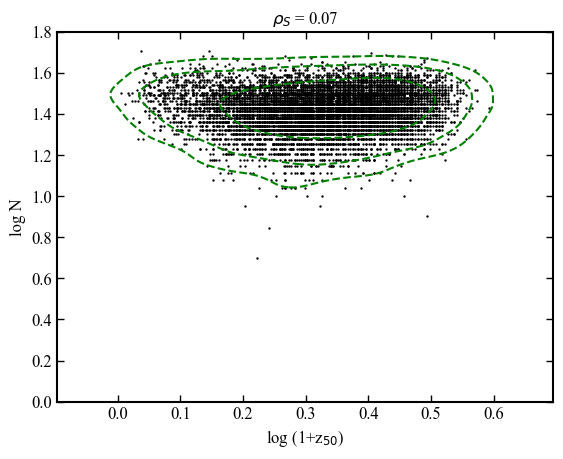

In [14]:
measure_abundance_correlation(S0, 1.2*10**8)

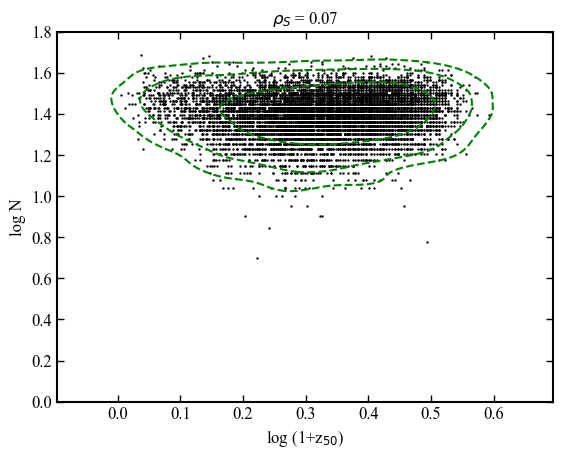

In [15]:
measure_abundance_correlation(S0, 1.6*10**8)

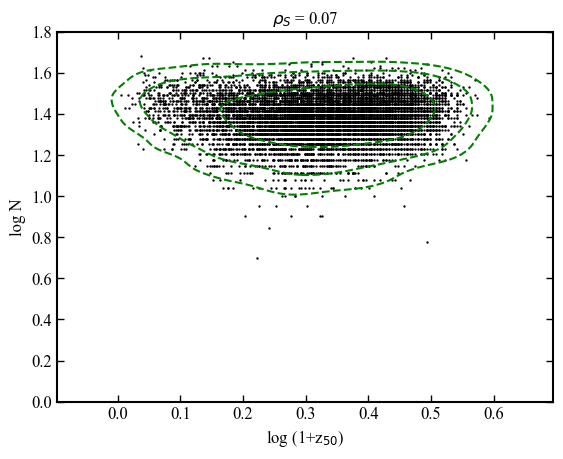

In [16]:
measure_abundance_correlation(S0, 1.8*10**8)

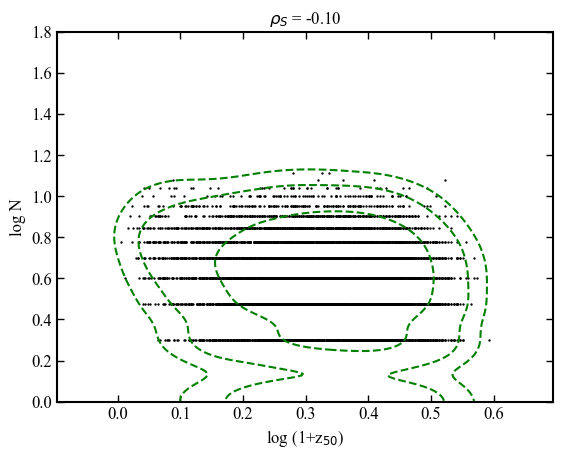

In [18]:
measure_abundance_correlation(S0, 10**9.5)

In [8]:
# measure_abundance_correlation(SHR, 10**9.5)

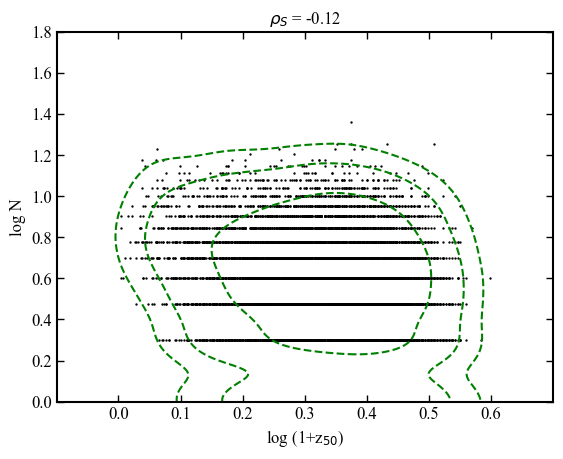

In [9]:
measure_abundance_correlation(S15, 10**9.5)

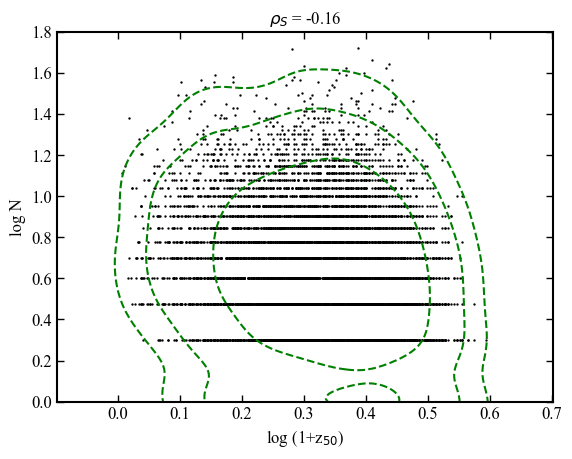

In [10]:
measure_abundance_correlation(S30, 10**9.5)

In [11]:
str = "tree_7749_evo.npz"

In [13]:
str.split("/")[-1].split("_")[1]

'7749'